# Task 2: DenseNet-121 for 60x80 Images

This notebook compares two completed DenseNet-121 experiments on the same frozen validation split: the original unweighted run and the run using a class-weight power of 0.36. The active configuration and checkpoint correspond to the experiment selected in Section 3.5; the alternative run remains as archival evidence and is not retrained.


## 0. Model introduction and motivation

DenseNet-121 is a convolutional network in which each layer receives the feature maps produced by all preceding layers within a dense block. These short connections encourage feature reuse, strengthen gradient flow, and allow later layers to combine low-level colour and texture cues with higher-level garment structure. For the 60x80 inputs, the final transition pooling operation is removed so that useful spatial information is not collapsed too early.

Notebook 02 established a Random Forest baseline from 2,007 engineered image features, reaching 66.77% accuracy and 0.6840 macro-F1. Notebook 03 then showed that an EfficientNet-B0 CNN could learn stronger task-specific spatial features, with its final weighted candidate reaching 74.73% accuracy and 0.7452 macro-F1. DenseNet-121 was chosen as a second CNN candidate because its dense feature reuse offers a different representation strategy and greater capacity. Its unweighted run reaches 75.61% accuracy and 0.7515 macro-F1: gains of 8.84 and 6.75 percentage points over Random Forest, and gains of 0.89 and 0.63 points over the final EfficientNet candidate, respectively.

The model uses `weights=None`; no ImageNet or other pretrained parameters are loaded. Every parameter is learned from the supplied training data, satisfying the assignment restriction on pretrained models.


## How to Run

Run `01_task2_setup.ipynb` first. A normal execution validates and restores the completed unweighted checkpoint, so the 40-epoch training is not repeated. Section 3.3 retains the weighted experiment's original output and learning curve as read-only evidence.


## Required Structure to Run

Run Notebook 01 first so that its prepared-data contract exists. `pyproject.toml` identifies the repository root, while `src/task2_utils.py` provides the model builder, data stream, training loop, evaluation logic, and checkpoint safeguards.

```text
Machine-Learning-Assignment-2/
├── pyproject.toml
├── src/
│   └── task2_utils.py
└── preprocessed_datasets/
    └── task2/
        ├── task2_metadata.json
        ├── task2_deep_learning_train_images.npy
        ├── task2_deep_learning_validation_images.npy
        ├── task2_random_forest_train_features.npy
        └── task2_random_forest_validation_features.npy
```

DenseNet trains on the two deep-learning image arrays. The Random Forest arrays are listed because the current shared loader validates the complete Notebook 01 package even though this model does not use those features. This notebook creates `models/task2/checkpoints/model_densenet121.pt`; the destination directory is created automatically. A compatible checkpoint may be restored instead of retrained.

## 1. Setup


In [1]:
%matplotlib inline
from IPython.display import display


In [2]:
from pathlib import Path
import sys

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "pyproject.toml").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not find the repository root containing pyproject.toml")
sys.path.insert(0, str(REPO_ROOT))

from src.task2_utils import (
    NeuralTrainer, build_task2_neural_model, ensure_task2_directories,
    model_checkpoint_path, neural_training_config, prepared_namespace, result_frame,
)
ensure_task2_directories()


### 1.1 Configuration

The settings below are controlled architecture-specific choices rather than the result of an exhaustive search:

- **40 epochs:** provides enough updates for the deeper network to converge; both experiments flatten late in training.
- **Batch size 128:** improves throughput and stabilises gradients while fitting the small 60x80 images in available accelerator memory.
- **AdamW, learning rate `1e-3`, and weight decay `1e-3`:** adaptive updates support from-scratch optimisation, while the stronger decay regularises DenseNet-121's greater capacity.
- **Four warm-up epochs followed by cosine decay:** the longer warm-up limits unstable early updates in the deeper network, followed by progressively smaller refinements.
- **Label smoothing `0.05`:** reduces overconfident predictions while preserving a relatively sharp target signal.
- **Class-weight power `0.0`:** the final active run uses ordinary unweighted cross-entropy. Section 3 compares this with power 0.36 and shows that the stronger weighting sacrifices 0.0111 macro-F1 for only 0.0024 additional balanced accuracy.
- **Flip probability `0.5`, rotation `12°`, translation `0.10`, and colour jitter `0.10`:** moderate augmentation introduces plausible catalogue-image variation without changing garment identity or season.
- **Classifier dropout `0.40`:** stronger dropout is used than in EfficientNet because DenseNet has higher capacity and a larger risk of fitting the training set too closely.
- **Patience 5 and macro-F1 checkpointing:** the best validation macro-F1 epoch is restored, and training may stop after five non-improving epochs. Macro-F1 gives every season equal importance.
- **Random seed 42:** fixes the experiment seed to improve repeatability.


In [ ]:
QUICK_RUN = False
RANDOM_STATE = 42
RESUME = False
# Require a supported GPU only if the compatible completed checkpoint is unavailable.
ALLOW_CPU = False

# Exact configuration of the selected unweighted DenseNet checkpoint.
HYPERPARAMETERS = {
    "epochs": 40,
    "warmup_epochs": 4,
    "batch_size": 128,
    "patience": 5,
    "learning_rate": 1e-3,
    "weight_decay": 1e-3,
    "label_smoothing": 0.05,
    "class_weight_power": 0.0,
    "flip_probability": 0.5,
    "rotation_degrees": 12.0,
    "translate_fraction": 0.10,
    "jitter_strength": 0.10,
}
CLASSIFIER_DROPOUT = 0.40

TRAINING_CONFIG = neural_training_config(
    quick_run=QUICK_RUN, random_state=RANDOM_STATE, resume=RESUME, allow_cpu=ALLOW_CPU,
)
TRAINING_CONFIG.update(HYPERPARAMETERS)
MODEL_CONFIG = {"architecture": "densenet121_small_input", **{
    key: value for key, value in TRAINING_CONFIG.items()
    if key not in {"resume", "allow_cpu", "keep_epoch_checkpoints"}
}, "classifier_dropout": CLASSIFIER_DROPOUT,
    "base_architecture": "densenet121",
    "spatial_change": "transition3_pool_identity",
}


## 2. Load Prepared Data and Shared Training Pipeline


In [4]:
data = prepared_namespace()
assert data.config.get("quick_run") == QUICK_RUN, (
    "QUICK_RUN does not match Notebook 1's prepared cache. "
    "Set the same value in both notebooks and rerun Notebook 1 if needed."
)
assert data.x_train.shape[1:] == (80, 60, 3), (
    f"Expected prepared 80x60 RGB images, got {data.x_train.shape[1:]}"
)
assert data.x_val.shape[1:] == (80, 60, 3), (
    f"Expected prepared 80x60 RGB images, got {data.x_val.shape[1:]}"
)
trainer = NeuralTrainer(data, TRAINING_CONFIG)
print(f"Loaded {len(data.train_frame):,} train and {len(data.validation_frame):,} validation rows")
print(f"Training batches per epoch: {len(trainer.train_loader)}")


Apple Metal GPU detected; using the PyTorch MPS backend.
Device: mps | mixed precision: False | run fingerprint: 5f507c7bb57f
Loaded 30,260 train and 7,566 validation rows
Training batches per epoch: 237


## 3. DenseNet-121 experiments

Both experiments use the small-input variant, which replaces the final transition pooling operation with an identity mapping to preserve spatial detail.


### 3.1 Original run — class-weight power 0.0

The original experiment used the active configuration above. Its completed output and learning curve are preserved below. On a future execution, `train_or_restore` validates the model configuration, validation IDs, and data fingerprint, then restores `model_densenet121.pt` without retraining.


DenseNet-121 Small Input: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_densenet121.pt has an incompatible model configuration; training a compatible checkpoint
[DenseNet-121 Small Input] starting epoch 1/40 (237 train + 15 validation batches)
[DenseNet-121 Small Input] finished epoch 1/40 | train loss 1.0416 | val loss 0.9295 | train accuracy 0.5481 | val accuracy 0.6269 | macro-F1 0.5736 | best 0.5736 (epoch 1) | lr 5.00e-04 | 42s
[DenseNet-121 Small Input] starting epoch 2/40 (237 train + 15 validation batches)
[DenseNet-121 Small Input] finished epoch 2/40 | train loss 0.9382 | val loss 1.0169 | train accuracy 0.6161 | val accuracy 0.5808 | macro-F1 0.4861 | best 0.5736 (epoch 1) | lr 7.50e-04 | 40s
[DenseNet-121 Small Input] starting epoch 3/40 (237 train + 15 validation batches)
[DenseNet-121 Small Input] finished epoch 3/40 | train loss 0.9044 | val loss 0.9248 | train accuracy 0.6395 | val accuracy 0.6163 | macro-F1 0.5512 | best 0.5736 (epoch 1) 

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy
0,DenseNet-121 Small Input,0.756146,0.751516,0.721136,0.754391,0.934444


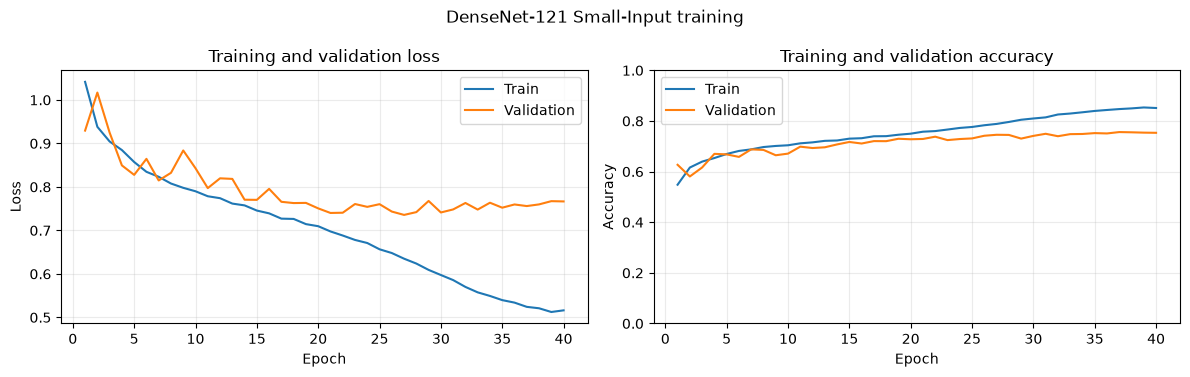

In [5]:
def build_model():
    return build_task2_neural_model(MODEL_CONFIG, data.n_classes)

densenet, history, logits = trainer.train_or_restore(
    "densenet121", build_model,
    "DenseNet-121 Small Input", MODEL_CONFIG
)
predictions = logits.argmax(axis=1)
display(result_frame(data.y_val, predictions, logits, "DenseNet-121 Small Input"))
trainer.plot_history(history, "DenseNet-121 Small-Input training")


### 3.2 Analysis of the original run

The restored epoch-37 checkpoint achieves 75.61% Top-1 accuracy, 0.7515 macro-F1, 0.7211 balanced accuracy, 0.7544 weighted F1, and 0.9344 Top-2 accuracy.

| Season | Correct | Support | Recall | Precision | F1 |
|---|---:|---:|---:|---:|---:|
| Fall | 1,371 | 2,052 | 66.81% | 73.04% | 69.79% |
| Spring | 215 | 312 | 68.91% | 90.72% | 78.32% |
| Summer | 3,118 | 3,732 | 83.55% | 75.13% | 79.12% |
| Winter | 1,017 | 1,470 | 69.18% | 78.11% | 73.38% |

Summer has the strongest recall but also attracts predictions from other seasons. Spring has high precision but lower recall, consistent with its small support. Fall remains the weakest class by F1. The gap between accuracy and balanced accuracy confirms that the dominant Summer class still influences the aggregate result, motivating the class-weighted experiment.


### 3.3 Weighted run — class-weight power 0.36

The second experiment changed only the loss weighting: weights were proportional to `class_count ** -0.36` and normalised to mean one. This more strongly emphasised rare seasons while keeping the architecture, data split, optimiser, augmentation, and epoch budget fixed. The cell below preserves the completed run's console output, metrics, and learning curve; its source is deliberately non-training archival metadata.


DenseNet-121 Small Input: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_densenet121.pt has an incompatible model configuration; training a compatible checkpoint
Training class weights: {'Fall': np.float64(0.816), 'Spring': np.float64(1.607), 'Summer': np.float64(0.658), 'Winter': np.float64(0.92)}
[DenseNet-121 Small Input] starting epoch 1/40 (237 train + 15 validation batches)
[DenseNet-121 Small Input] finished epoch 1/40 | train loss 1.1430 | val loss 0.9731 | train accuracy 0.5265 | val accuracy 0.6090 | macro-F1 0.5849 | best 0.5849 (epoch 1) | lr 5.00e-04 | 42s
[DenseNet-121 Small Input] starting epoch 2/40 (237 train + 15 validation batches)
[DenseNet-121 Small Input] finished epoch 2/40 | train loss 1.0291 | val loss 1.1255 | train accuracy 0.5988 | val accuracy 0.5334 | macro-F1 0.4754 | best 0.5849 (epoch 1) | lr 7.50e-04 | 40s
[DenseNet-121 Small Input] starting epoch 3/40 (237 train + 15 validation batches)
[DenseNet-121 Small Input] finished

,Model,Top-1 accuracy,Macro-F1,Balanced accuracy,Weighted F1,Top-2 accuracy
0,DenseNet-121 Small Input,0.748348,0.74037,0.723577,0.747599,0.926117


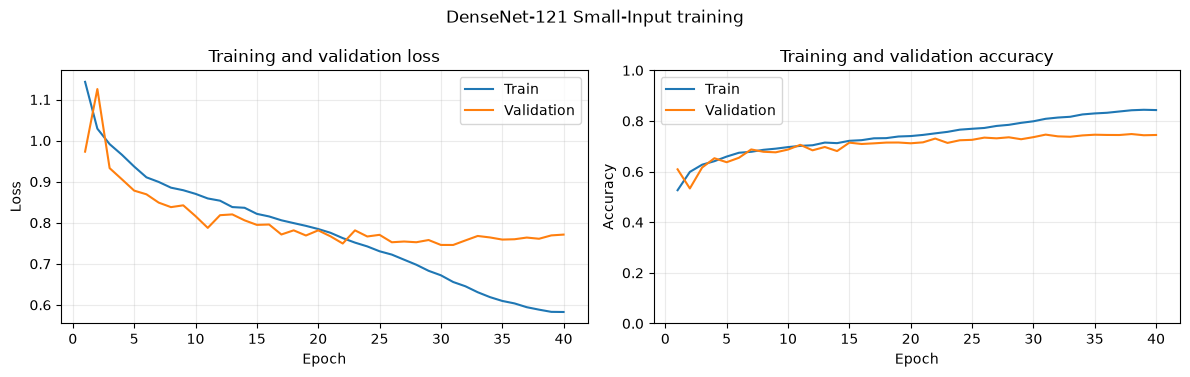

In [5]:
# Archived output from the completed class-weighted experiment.
# This cell is evidence only and intentionally performs no training when rerun.
WEIGHTED_EXPERIMENT_CONFIG = {
    "class_weight_power": 0.36,
    "epochs": 40,
    "best_epoch": 38,
}
WEIGHTED_EXPERIMENT_CONFIG


### 3.4 Weighted-run analysis and comparison

The weighted run's restored epoch-38 results are:

| Season | Correct | Support | Recall | Precision | F1 |
|---|---:|---:|---:|---:|---:|
| Fall | 1,399 | 2,052 | 68.18% | 71.27% | 69.69% |
| Spring | 216 | 312 | 69.23% | 82.44% | 75.26% |
| Summer | 2,990 | 3,732 | 80.12% | 76.37% | 78.20% |
| Winter | 1,057 | 1,470 | 71.90% | 74.12% | 73.00% |

| Metric | Unweighted (0.0) | Weighted (0.36) | Weighted change |
|---|---:|---:|---:|
| Top-1 accuracy | 0.756146 | 0.748348 | -0.007798 |
| Macro-F1 | 0.751516 | 0.740370 | -0.011146 |
| Balanced accuracy | 0.721136 | 0.723577 | +0.002441 |
| Weighted F1 | 0.754391 | 0.747599 | -0.006792 |
| Top-2 accuracy | 0.934444 | 0.926117 | -0.008327 |

Weighting raises recall for Fall, Spring, and Winter, but reduces Summer recall by 3.43 percentage points. The balanced-accuracy gain is only 0.24 points, while macro-F1 falls by 1.11 points and accuracy falls by 0.78 points. Spring precision also drops from 90.72% to 82.44%, showing that the extra Spring predictions introduce more false positives. Unlike the near-tie observed for EfficientNet, the DenseNet weighting trade-off is not favourable on the primary metric.

Absolute training-loss heights are not directly comparable because class weighting changes the loss definition. The learning curves can still reveal convergence and overfitting, but neither curve provides evidence strong enough to override the validation-metric disadvantage of the weighted run.


### 3.5 Conclusion and final DenseNet-121 checkpoint

The final DenseNet-121 checkpoint is the **unweighted run with `class_weight_power = 0.0`, restored from epoch 37**. It is stored at `models/task2/checkpoints/model_densenet121.pt` and uses data fingerprint `5f507c7bb57f`.

This checkpoint is selected because it has the higher macro-F1, Top-1 accuracy, weighted F1, and Top-2 accuracy. The weighted run improves balanced accuracy by only 0.002441, which does not compensate for its 0.011146 macro-F1 reduction. The unweighted run also retains substantially higher Spring precision and the strongest overall class-level F1 trade-off.

This is the final **DenseNet candidate**, not an independent declaration of the overall Task 2 winner. Notebook 05 remains responsible for comparing the fixed Random Forest, EfficientNet, and DenseNet candidates under the common selection rule.


## 4. Confirm the completed checkpoint

The chosen DenseNet worker checkpoint already exists in the shared checkpoint directory. Notebook 05 remains the sole owner of the final selected-model package.


In [4]:
import torch

checkpoint_path = model_checkpoint_path("densenet121")
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
assert checkpoint["fingerprint"] == data.fingerprint
assert checkpoint["model_config"] == MODEL_CONFIG
assert checkpoint["model_config"]["class_weight_power"] == 0.0
print("Completed checkpoint:", checkpoint_path)
print("Class-weight power:", checkpoint["model_config"]["class_weight_power"])
print("Run fingerprint:", checkpoint["fingerprint"])


Completed checkpoint: /Users/s4030327/Machine-Learning-Assignment-2/models/task2/checkpoints/model_densenet121.pt
Class-weight power: 0.0
Run fingerprint: 5f507c7bb57f
